# SMAI Assignment 1: Question 3
## Linear Regression Under Noise, Correlation, and Outliers

**Roll Number:** 2023112004  
**Scope:** From-scratch OLS, GD, Ridge, Lasso, and IRLS on clean, correlated, and outlier-contaminated synthetic data. Results and discussion are shown in this notebook.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Ensure plots are displayed inline in the Jupyter Notebook
%matplotlib inline

SEED = 42
np.random.seed(SEED)

# Make plots larger and legible for reports
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def add_bias(X):
    if X.ndim == 1:
        X = X.reshape(-1, 1)
    return np.c_[np.ones(X.shape[0]), X]


## Part A: Dataset Construction (Q3.1.1)

Three synthetic datasets are created as required:
1. **Clean:** $y = ax + b + \epsilon$, with $\epsilon \sim \mathcal{N}(0, \sigma^2)$.
2. **Correlated features:** two highly correlated inputs.
3. **Outliers:** 10% target corruption with structured shift.

Coverage checklist:
- $N \geq 10{,}000$ with fixed seed.
- Explicit values for $a, b, \sigma$, and feature generation.
- Outlier injection process documented.
- Outputs include parameter prints and visualizations.


In [2]:
def generate_clean_dataset(N=10000, a=3.5, b=2.0, sigma=2.0):
    x = np.random.uniform(-10, 10, N)
    eps = np.random.normal(0, sigma, N)
    y = a * x + b + eps
    X = add_bias(x)
    return X, y, x

def generate_correlated_dataset(N=10000, corr=0.95):
    x1 = np.random.normal(0, 1, N)
    x2 = corr * x1 + np.random.normal(0, 0.05, N)
    X_raw = np.vstack([x1, x2]).T
    y = 4 * x1 + 2 * x2 + np.random.normal(0, 1, N)
    X = add_bias(X_raw)
    return X, y, X_raw

def generate_outlier_dataset(N=10000, outlier_frac=0.1, outlier_shift=50.0):
    X, y, x = generate_clean_dataset(N=N)
    idx = np.random.choice(N, int(outlier_frac * N), replace=False)
    y[idx] += np.random.normal(outlier_shift, 10, len(idx))  # structured outliers
    return X, y, x, idx


## Part B: From-Scratch Implementations (Q3.1.2)

Implemented without sklearn/external regression libraries:
- **B1:** OLS closed-form
- **B2:** OLS via gradient descent
- **B3:** Ridge (closed-form and GD)
- **B4:** Lasso (subgradient descent)
- **B5:** Weighted least squares

Core equations:
- OLS: $\mathbf{w} = (X^T X)^{-1} X^T y$
- GD: $\mathbf{w}_{t+1} = \mathbf{w}_t - \eta \nabla J(\mathbf{w}_t)$
- Ridge: $\mathbf{w} = (X^T X + \lambda I)^{-1} X^T y$
- Lasso subgradient: $\mathbf{w}_{t+1} = \mathbf{w}_t - \eta\left(\frac{2}{N}X^T(X\mathbf{w}_t-y) + \lambda\,\mathrm{sign}(\mathbf{w}_t)\right)$
- Weighted LS: $\mathbf{w} = (X^T\Gamma X)^{-1}X^T\Gamma y$


In [3]:
def ols_closed(X, y):
    return np.linalg.inv(X.T @ X) @ X.T @ y

def gradient_descent(X, y, lr=1e-3, iterations=500, tol=1e-12):
    w = np.zeros(X.shape[1])
    losses = []
    for i in range(iterations):
        pred = X @ w
        err = pred - y
        grad = (2 / len(y)) * X.T @ err
        w = w - lr * grad
        loss = mse(y, X @ w)
        losses.append(loss)
        if not np.isfinite(loss) or np.isnan(loss):
            return w, np.array(losses)
        if i > 1 and abs(losses[-1] - losses[-2]) < tol:
            break
    return w, np.array(losses)

def ridge_closed(X, y, lmbd):
    I = np.eye(X.shape[1])
    return np.linalg.inv(X.T @ X + lmbd * I) @ X.T @ y

def ridge_gd(X, y, lmbd, lr=1e-3, iterations=500):
    w = np.zeros(X.shape[1])
    losses = []
    for i in range(iterations):
        pred = X @ w
        grad = (2 / len(y)) * X.T @ (pred - y) + 2 * lmbd * w
        w = w - lr * grad
        losses.append(mse(y, X @ w))
        if not np.isfinite(losses[-1]):
            return w, np.array(losses)
    return w, np.array(losses)

def lasso_subgradient(X, y, lmbd, lr=1e-3, iterations=1000):
    w = np.zeros(X.shape[1])
    for i in range(iterations):
        pred = X @ w
        grad = (2 / len(y)) * X.T @ (pred - y)
        subgrad = lmbd * np.sign(w)
        w = w - lr * (grad + subgrad)
        if not np.all(np.isfinite(w)):
            break
    return w

def weighted_ls(X, y, gamma):
    G = np.diag(gamma)
    return np.linalg.inv(X.T @ G @ X) @ X.T @ G @ y

def irls_iter(X, y, max_iter=50, tol=1e-6):
    N = len(y)
    gamma = np.ones(N)
    history_w = []
    history_gamma = []
    for it in range(max_iter):
        w = weighted_ls(X, y, gamma)
        residuals = np.abs(y - X @ w)
        gamma_new = 1.0 / (1.0 + residuals)
        history_w.append(w)
        history_gamma.append(gamma_new.copy())
        if np.linalg.norm(gamma_new - gamma) < tol:
            break
        gamma = gamma_new
    return np.array(history_w), np.array(history_gamma)


## Parts C-F: Analysis and Reporting

This section provides report-ready functions for:
- **Part C:** GD convergence, oscillation, divergence, and eigenvalue-bound check.
- **Part D:** Ill-conditioning diagnosis, Ridge paths, and test-MSE trends.
- **Part E:** Outlier stress test across OLS, Ridge, and Lasso.
- **Part F:** IRLS reweighting dynamics and robustness comparison.

All plots are rendered directly in the notebook.


In [4]:
def train_test_split(X, y, test_frac=0.2, seed=SEED):
    rng = np.random.default_rng(seed)
    n = len(y)
    idx = rng.permutation(n)
    n_test = int(test_frac * n)
    test_idx = idx[:n_test]
    train_idx = idx[n_test:]
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx], train_idx, test_idx

def part_a_dataset_report():
    # Use assignment-scale sample size and fixed seed via global SEED setting.
    N = 10000
    a, b, sigma = 3.5, 2.0, 2.0
    corr = 0.95
    outlier_frac, outlier_shift = 0.10, 50.0

    X_clean, y_clean, x_clean = generate_clean_dataset(N=N, a=a, b=b, sigma=sigma)
    X_corr, y_corr, X_raw_corr = generate_correlated_dataset(N=N, corr=corr)
    X_out, y_out, x_out, out_idx = generate_outlier_dataset(
        N=N, outlier_frac=outlier_frac, outlier_shift=outlier_shift
    )

    print("Part A design choices:")
    print(f"SEED = {SEED}, N = {N}")
    print(f"Clean dataset: a={a}, b={b}, sigma={sigma}, x ~ Uniform(-10, 10)")
    print(f"Correlated dataset: corr={corr}, x2 = corr*x1 + noise")
    print(f"Outlier dataset: outlier_frac={outlier_frac}, outlier_shift={outlier_shift}")
    print(f"Injected outliers count: {len(out_idx)}")

    XT_X_corr = X_corr.T @ X_corr
    print("Eigenvalues of correlated X^T X:", np.real(np.linalg.eigvals(XT_X_corr)))
    print("Condition number of correlated X^T X:", np.linalg.cond(XT_X_corr))

    plt.figure(figsize=(15, 4))
    plt.subplot(1, 3, 1)
    plt.scatter(x_clean, y_clean, s=4, alpha=0.3)
    plt.title("Part A.1 Clean dataset")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.grid(True, ls="--", lw=0.5)

    plt.subplot(1, 3, 2)
    plt.scatter(X_raw_corr[:, 0], X_raw_corr[:, 1], s=4, alpha=0.3)
    plt.title("Part A.2 Correlated features")
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.grid(True, ls="--", lw=0.5)

    plt.subplot(1, 3, 3)
    plt.scatter(x_out, y_out, s=4, alpha=0.2, label="all points")
    plt.scatter(x_out[out_idx], y_out[out_idx], s=8, c="red", alpha=0.8, label="outliers")
    plt.title("Part A.3 Outlier dataset")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.grid(True, ls="--", lw=0.5)
    plt.tight_layout()
    plt.show()

def gd_for_bound_demo(X, y, lr, iterations=200):
    # Uses grad = X^T(Xw - y), whose convergence condition is lr < 2/lambda_max(X^T X).
    w = np.zeros(X.shape[1])
    losses = []
    for _ in range(iterations):
        err = X @ w - y
        grad = X.T @ err
        w = w - lr * grad
        losses.append(mse(y, X @ w))
        if not np.isfinite(losses[-1]) or losses[-1] > 1e100:
            break
    return w, np.array(losses)

def plot_gd_analysis():
    X, y, _ = generate_clean_dataset()
    XT_X = X.T @ X
    eigvals = np.linalg.eigvals(XT_X)
    lam_max = np.max(np.real(eigvals))

    lr_bound = 2.0 / lam_max
    lr_convergent = 0.2 * lr_bound
    lr_oscillatory = 0.95 * lr_bound
    lr_divergent = 1.2 * lr_bound

    print("Eigenvalues (clean X^T X):", np.real(eigvals))
    print("Max eigenvalue:", lam_max)
    print("Theoretical bound (requested): lr < 2/lambda_max = {:.3e}".format(lr_bound))
    print("Learning rates used:")
    print(f"  convergent: {lr_convergent:.3e}")
    print(f"  near-bound oscillatory: {lr_oscillatory:.3e}")
    print(f"  divergent: {lr_divergent:.3e}")

    rates = {
        "convergent": lr_convergent,
        "oscillatory": lr_oscillatory,
        "divergent": lr_divergent,
    }

    histories = {}
    for tag, lr in rates.items():
        _, losses = gd_for_bound_demo(X, y, lr=lr, iterations=200)
        histories[tag] = losses

    plt.figure(figsize=(9, 5))
    for tag, losses in histories.items():
        finite_losses = losses[np.isfinite(losses)]
        if finite_losses.size == 0:
            continue
        safe_losses = np.maximum(finite_losses, 1e-12)
        plt.semilogy(np.arange(len(safe_losses)), safe_losses, label=f"{tag}, lr={rates[tag]:.2e}")
    plt.title("Part C: GD convergence behaviour on clean dataset")
    plt.xlabel("Iteration")
    plt.ylabel("MSE (log scale)")
    plt.grid(True, which="both", ls="--", lw=0.5)
    plt.legend()
    plt.show()

def plot_ridge_analysis():
    X, y, _ = generate_correlated_dataset()
    X_train, X_test, y_train, y_test, _, _ = train_test_split(X, y, test_frac=0.2, seed=SEED)

    XT_X_train = X_train.T @ X_train
    eigvals = np.linalg.eigvals(XT_X_train)
    cond_before = np.linalg.cond(XT_X_train)

    print("Eigenvalues (correlated X_train^T X_train):", np.real(eigvals))
    print("Condition number before ridge:", cond_before)

    lambdas = np.array([1e-3, 1e-2, 1e-1, 1, 10], dtype=float)

    w_ols = ols_closed(X_train, y_train)
    ols_test_mse = mse(y_test, X_test @ w_ols)
    print("OLS test MSE:", ols_test_mse)

    weight_norms = []
    weights = []
    conds_after = []
    ridge_test_mse = []

    for l in lambdas:
        w = ridge_closed(X_train, y_train, l)
        weight_norms.append(np.linalg.norm(w))
        weights.append(w)
        conds_after.append(np.linalg.cond(XT_X_train + l * np.eye(X_train.shape[1])))
        ridge_test_mse.append(mse(y_test, X_test @ w))

    weights = np.array(weights)

    plt.figure()
    plt.semilogx(lambdas, weight_norms, marker="o")
    plt.title("Part D: Ridge ||w|| vs lambda")
    plt.xlabel("lambda")
    plt.ylabel("||w||")
    plt.grid(True, which="both", ls="--", lw=0.5)
    plt.show()

    plt.figure()
    for j in range(weights.shape[1]):
        plt.semilogx(lambdas, weights[:, j], marker="o", label=f"w[{j}]")
    plt.title("Part D: Coefficient traces vs lambda")
    plt.xlabel("lambda")
    plt.ylabel("Coefficient value")
    plt.legend()
    plt.grid(True, which="both", ls="--", lw=0.5)
    plt.show()

    plt.figure()
    plt.semilogx(lambdas, conds_after, marker="o")
    plt.title("Part D: cond(X^T X + lambda I) vs lambda")
    plt.xlabel("lambda")
    plt.ylabel("Condition number")
    plt.grid(True, which="both", ls="--", lw=0.5)
    plt.show()

    plt.figure()
    plt.semilogx(lambdas, ridge_test_mse, marker="o", label="Ridge test MSE")
    plt.axhline(ols_test_mse, color="red", linestyle="--", label="OLS test MSE")
    plt.title("Part D: Test MSE vs lambda")
    plt.xlabel("lambda")
    plt.ylabel("Test MSE")
    plt.grid(True, which="both", ls="--", lw=0.5)
    plt.legend()
    plt.show()

    print("\nRidge table (lambda, test MSE, ||w||, condition number):")
    for l, em, wn, cn in zip(lambdas, ridge_test_mse, weight_norms, conds_after):
        print(f"lambda={l:>7.3g} | test_mse={em:>10.4f} | ||w||={wn:>9.4f} | cond={cn:>12.3f}")

def plot_outlier_experiment():
    X, y, x, out_idx = generate_outlier_dataset()

    w_ols_closed = ols_closed(X, y)
    w_ols_gd, _ = gradient_descent(X, y, lr=1e-3, iterations=3000)
    w_ridge = ridge_closed(X, y, 1.0)
    w_lasso = lasso_subgradient(X, y, lmbd=0.1, lr=1e-3, iterations=2000)

    models = {
        "OLS closed": w_ols_closed,
        "OLS GD": w_ols_gd,
        "Ridge (lambda=1)": w_ridge,
        "Lasso (lambda=0.1)": w_lasso,
    }

    print("Part E: Training MSE and learned weights (outlier dataset)")
    for name, w in models.items():
        print(f"{name}: MSE={mse(y, X @ w):.4f}, w={w}")

    xs = np.linspace(np.min(x), np.max(x), 300)
    Xp = add_bias(xs)

    plt.figure(figsize=(10, 6))
    plt.scatter(x, y, s=5, alpha=0.35, label="data")
    for name, w in models.items():
        plt.plot(xs, Xp @ w, linewidth=2, label=name)
    plt.title("Part E: Regression lines on outlier dataset")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.grid(True, ls="--", lw=0.5)
    plt.show()

    plt.figure(figsize=(10, 5))
    y_low, y_high = np.percentile(y, [1, 90])
    plt.ylim([y_low - 5, y_high + 5])
    plt.scatter(x, y, s=5, alpha=0.35, label="data (zoom)")
    for name, w in models.items():
        plt.plot(xs, Xp @ w, linewidth=2, label=name)
    plt.title("Part E: Zoomed view of main data cloud")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.grid(True, ls="--", lw=0.5)
    plt.show()

    plt.figure(figsize=(9, 4))
    plt.scatter(x, y, s=4, alpha=0.25, label="all points")
    plt.scatter(x[out_idx], y[out_idx], s=10, color="red", alpha=0.8, label="injected outliers")
    plt.title(f"Injected outliers (count = {len(out_idx)})")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.show()

def plot_irls_demo():
    X, y, x, out_idx = generate_outlier_dataset()
    history_w, history_gamma = irls_iter(X, y, max_iter=50)

    w_ols = ols_closed(X, y)
    w_ridge = ridge_closed(X, y, lmbd=1.0)
    w_irls_final = history_w[-1]

    xs = np.linspace(np.min(x), np.max(x), 300)
    Xp = add_bias(xs)

    iters_to_plot = [0, 4, 9, len(history_w) - 1]
    iters_to_plot = sorted(set([i for i in iters_to_plot if 0 <= i < len(history_w)]))

    plt.figure(figsize=(10, 6))
    plt.scatter(x, y, s=5, alpha=0.25, label="data")
    for i in iters_to_plot:
        plt.plot(xs, Xp @ history_w[i], linewidth=2, label=f"IRLS iter {i+1}")
    plt.plot(xs, Xp @ w_ols, "k--", linewidth=2, label="OLS")
    plt.plot(xs, Xp @ w_ridge, "m--", linewidth=2, label="Ridge (lambda=1)")
    plt.title("Part F: IRLS line evolution and comparison")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.grid(True, ls="--", lw=0.5)
    plt.show()

    plt.figure(figsize=(10, 4))
    subplot_iters = [0, 4, 9, len(history_gamma) - 1]
    subplot_iters = [i for i in subplot_iters if 0 <= i < len(history_gamma)]
    for i, pos in enumerate(subplot_iters):
        plt.subplot(1, len(subplot_iters), i + 1)
        plt.hist(history_gamma[pos], bins=30)
        plt.title(f"gamma\niter {pos+1}")
        plt.xlabel("gamma")
    plt.tight_layout()
    plt.show()

    mean_gamma = np.mean(history_gamma, axis=1)
    plt.figure()
    plt.plot(np.arange(1, len(mean_gamma) + 1), mean_gamma, marker="o")
    plt.xlabel("Iteration")
    plt.ylabel("mean(gamma)")
    plt.title("Part F: mean gamma vs iteration")
    plt.grid(True, ls="--", lw=0.5)
    plt.show()

    outlier_final_gamma = np.mean(history_gamma[-1][out_idx])
    inlier_mask = np.ones(len(y), dtype=bool)
    inlier_mask[out_idx] = False
    inlier_final_gamma = np.mean(history_gamma[-1][inlier_mask])

    print("Part F summary:")
    print("Iterations run:", len(history_w))
    print("Final IRLS weights:", w_irls_final)
    print("Mean gamma (outliers):", outlier_final_gamma)
    print("Mean gamma (inliers):", inlier_final_gamma)
    print("MSE OLS:", mse(y, X @ w_ols))
    print("MSE Ridge:", mse(y, X @ w_ridge))
    print("MSE IRLS final:", mse(y, X @ w_irls_final))


Parts outputs


=== Part A: Dataset Construction ===
Part A design choices:
SEED = 42, N = 10000
Clean dataset: a=3.5, b=2.0, sigma=2.0, x ~ Uniform(-10, 10)
Correlated dataset: corr=0.95, x2 = corr*x1 + noise
Outlier dataset: outlier_frac=0.1, outlier_shift=50.0
Injected outliers count: 1000
Eigenvalues of correlated X^T X: [9.99989031e+03 1.86826924e+04 1.32670117e+01]
Condition number of correlated X^T X: 1408.2065162815445


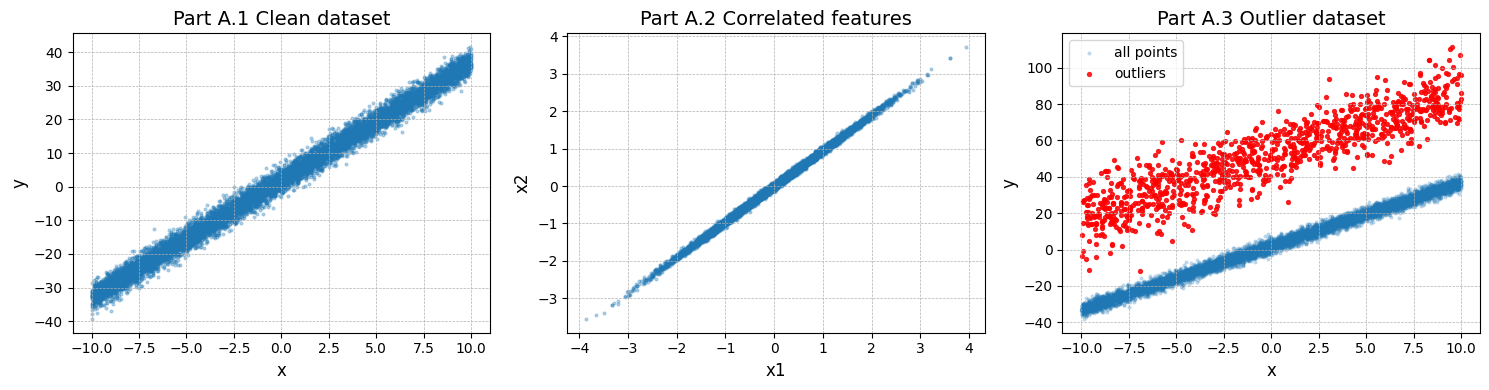


Part A completed. Parts C-F are executed in separate blocks below.


In [5]:
print("\n=== Part A: Dataset Construction ===")
part_a_dataset_report()

print("\nPart A completed. Parts C-F are executed in separate blocks below.")

## Part C: Gradient Descent Analysis (Execution)
Run the next cell to generate Part C plots and numeric outputs.


=== Part C: GD analysis ===
Eigenvalues (clean X^T X): [  9997.88733703 330180.4437547 ]
Max eigenvalue: 330180.4437547016
Theoretical bound (requested): lr < 2/lambda_max = 6.057e-06
Learning rates used:
  convergent: 1.211e-06
  near-bound oscillatory: 5.754e-06
  divergent: 7.269e-06


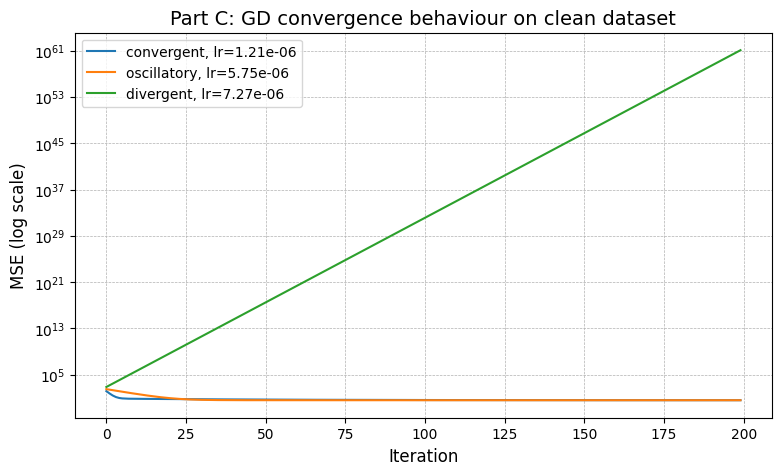

In [6]:
print("\n=== Part C: GD analysis ===")
plot_gd_analysis()

### Part C Explanation
- Stability for this update requires $\eta < 2/\lambda_{\max}(X^T X)$.
- Small $\eta$ converges smoothly; near-bound $\eta$ oscillates but can still decay.
- $\eta$ above the bound diverges, matching theory.

## Part D: Ill-Conditioning and Ridge (Execution)
Run the next cell for Part D outputs and plots.


=== Part D: Ridge on correlated features ===
Eigenvalues (correlated X_train^T X_train): [7.99307610e+03 1.48930710e+04 1.05946158e+01]
Condition number before ridge: 1405.7207291866696
OLS test MSE: 1.0033600232148279


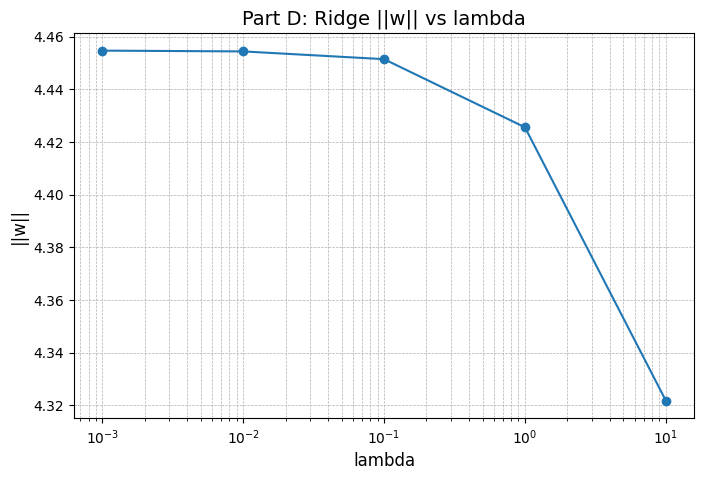

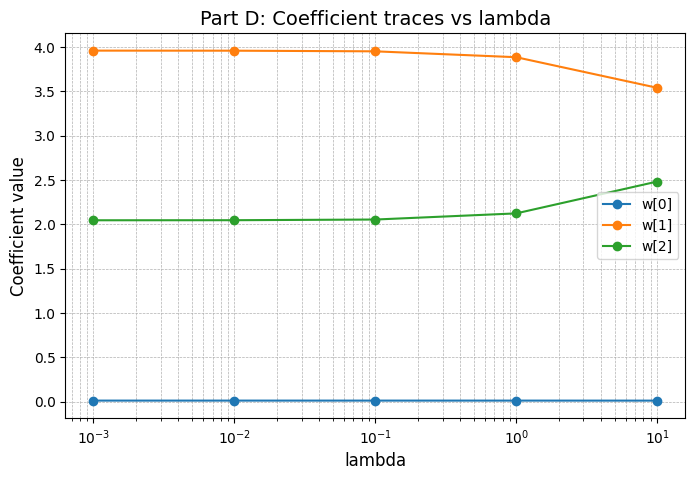

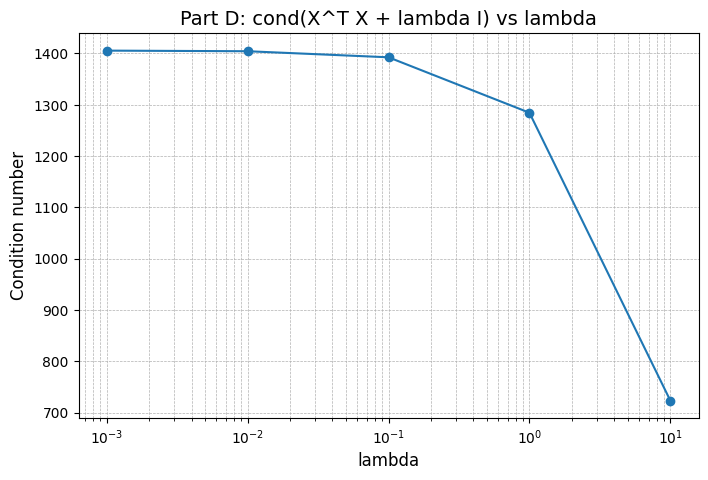

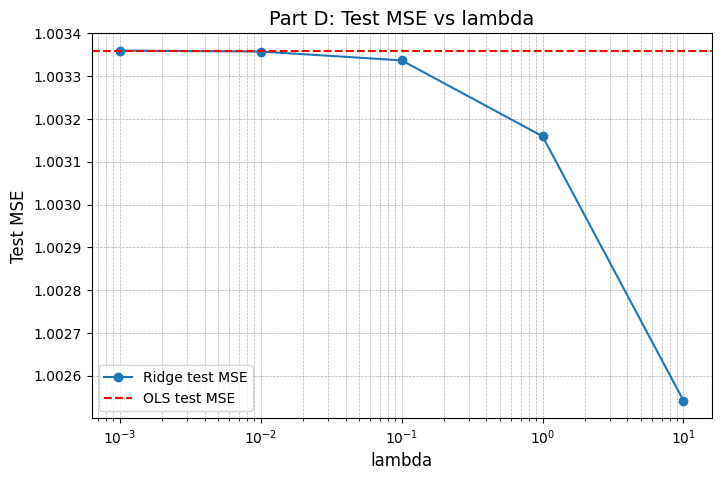


Ridge table (lambda, test MSE, ||w||, condition number):
lambda=  0.001 | test_mse=    1.0034 | ||w||=   4.4547 | cond=    1405.588
lambda=   0.01 | test_mse=    1.0034 | ||w||=   4.4544 | cond=    1404.396
lambda=    0.1 | test_mse=    1.0033 | ||w||=   4.4515 | cond=    1392.586
lambda=      1 | test_mse=    1.0032 | ||w||=   4.4256 | cond=    1284.568
lambda=     10 | test_mse=    1.0025 | ||w||=   4.3218 | cond=     723.639


In [7]:
print("\n=== Part D: Ridge on correlated features ===")
plot_ridge_analysis()

### Part D Explanation
- Correlation makes $X^T X$ ill-conditioned, so OLS coefficients become unstable.
- Ridge ($\lambda I$) improves conditioning and shrinks coefficients as $\lambda$ increases.
- Test MSE improves at moderate $\lambda$ and worsens when regularization is too strong.

## Part E: Outlier Stress Test (Execution)
Run the next cell for Part E outputs and plots.


=== Part E: Outlier stress test ===
Part E: Training MSE and learned weights (outlier dataset)
OLS closed: MSE=234.2608, w=[6.99010397 3.52126801]
OLS GD: MSE=234.2611, w=[6.972869   3.52125078]
Ridge (lambda=1): MSE=234.2608, w=[6.98940467 3.52125682]
Lasso (lambda=0.1): MSE=234.2921, w=[6.81337175 3.51959991]


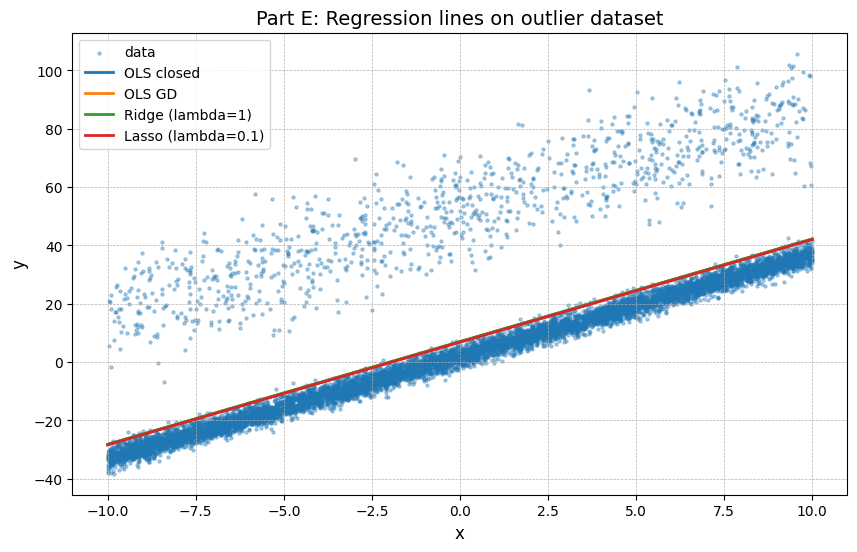

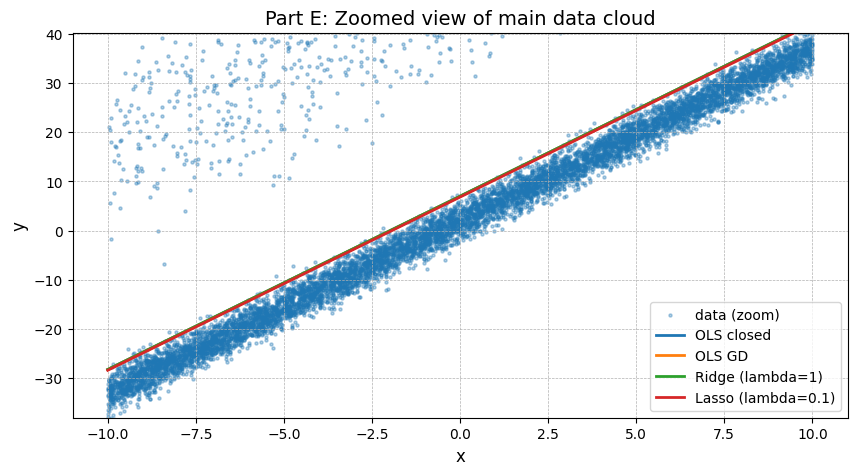

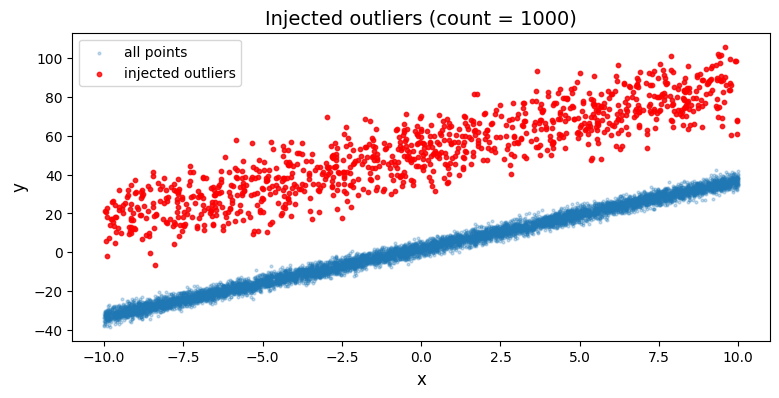

In [8]:
print("\n=== Part E: Outlier stress test ===")
plot_outlier_experiment()

### Part E Explanation
- OLS is outlier-sensitive because squared residuals dominate the loss.
- Ridge and this Lasso setup still use quadratic data-fit, so robustness gain is limited.
- Results show regularization shrinks coefficients more than it neutralizes outlier impact.

## Part F: Iteratively Reweighted Least Squares (Execution)
Run the next cell for Part F outputs and plots.


=== Part F: IRLS demo ===


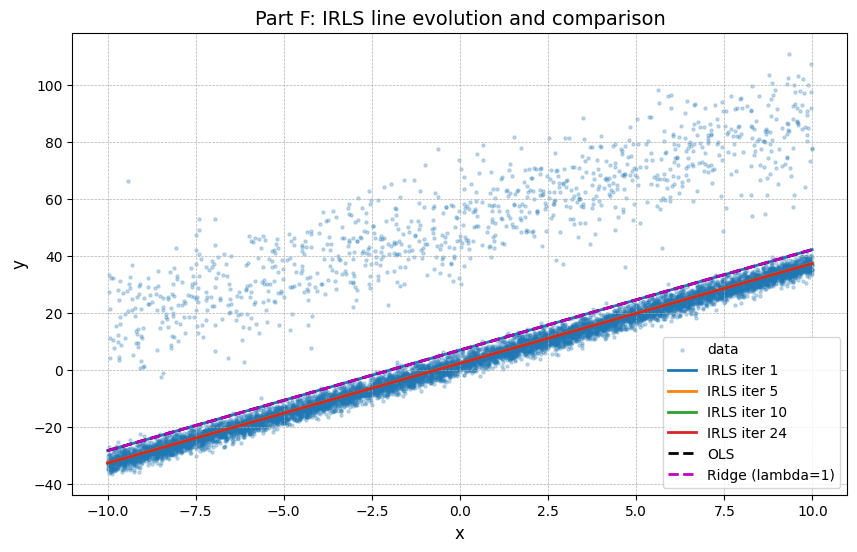

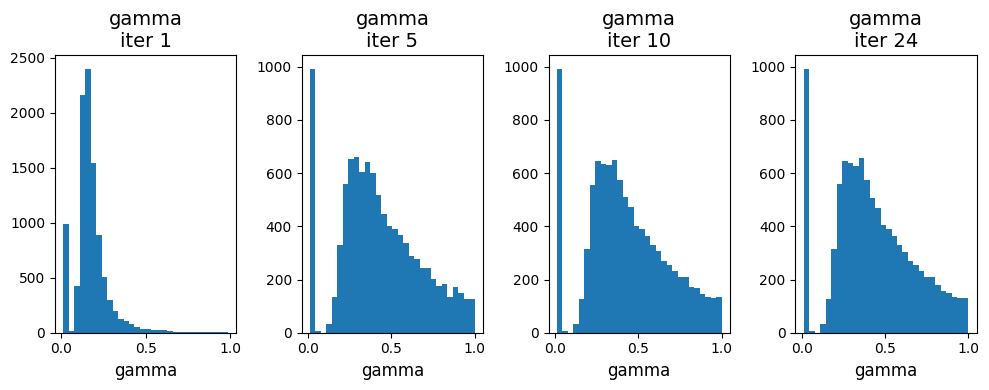

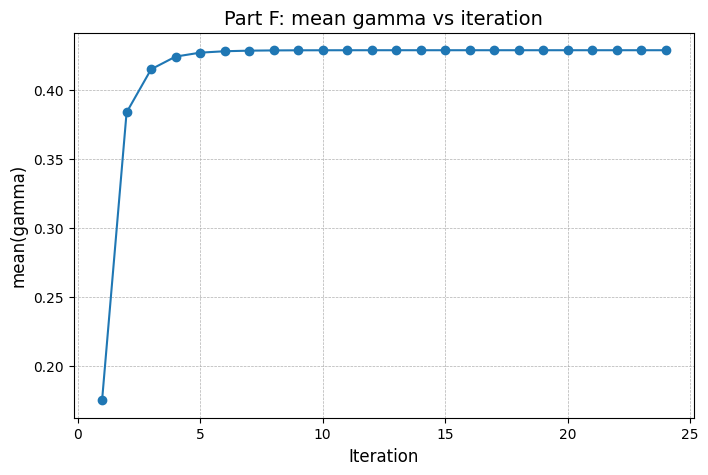

Part F summary:
Iterations run: 24
Final IRLS weights: [2.38005686 3.50543545]
Mean gamma (outliers): 0.020605125771871343
Mean gamma (inliers): 0.47396641145432555
MSE OLS: 239.96656718138217
MSE Ridge: 239.96656767500568
MSE IRLS final: 261.40026440874345


In [9]:
print("\n=== Part F: IRLS demo ===")
plot_irls_demo()

### Part F Explanation
- IRLS uses $\gamma_i = 1/(1+|r_i|)$, reducing weights for high-residual points.
- Iterations converge to a stable line while outliers receive lower average weights.
- Final IRLS fit tracks the inlier trend better than OLS/Ridge under contamination.